## 1. Setup and Imports 

In [34]:
# Other libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path
import joblib
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix


In [35]:
# Our own libraries
from models.augment_dataset import select_cryptomining_like_traffic, add_realistic_noise, augment_with_feature_correlation, map_nids_to_features, get_feature_columns
from models.data_preprocessor import download_unsw_nb15_dataset, load_cn21_dataset

In [36]:
# Download dataset and set root directory
print("\n[1/2] Checking UNSW-NB15 dataset...")
download_unsw_nb15_dataset()

current_path = Path(os.getcwd())


[1/2] Checking UNSW-NB15 dataset...
UNSW-NB15 dataset already downloaded


## 2. Load & Process CNT21 Dataset

In [ ]:
print("\n[2/2] Processing CN21 dataset...")
dataset_root = current_path / 'dataset'
cn21_df = load_cn21_dataset(dataset_root)
output_path = dataset_root / 'cn21_processed.csv'
cn21_df.to_csv(output_path, index=False)
print(f"Loaded {len(cn21_df)} flows: {(cn21_df['label']==0).sum()} benign, {(cn21_df['label']==1).sum()} malicious")
print(f"Saved to: {output_path}")

print("\n" + "=" * 70)
print("✓ Preprocessing complete")
print("=" * 70)
print("\nNext steps:")
print("  python3 models/augment_dataset.py")
print("  python3 train_models.py --augmented")


[2/2] Processing CN21 dataset...
Loaded 54 flows: 18 benign, 36 malicious
Loaded 54 flows: 18 benign, 36 malicious
Saved to: /Users/megh/nyu/Astra/dataset/cn21_processed.csv

✓ Preprocessing complete

Next steps:
  python3 models/augment_dataset.py
  python3 train_models.py --augmented


## 3. Augment Dataset with Noisy and Cryptomining-like Data from UNSW-NB15

In [37]:
# Use existing implementation from augment_dataset.py
from models.augment_dataset import main as augment_dataset

# Run the complete augmentation pipeline (noise + NIDS selection)
# This saves to dataset/cn21_augmented.csv
augment_dataset()

# Load the augmented dataset for visualization
df = pd.read_csv('dataset/cn21_augmented.csv')
print(f"\n✓ Loaded augmented dataset: {len(df)} flows")

DATA AUGMENTATION - MODEL-GUIDED SELECTION
CN21: 54 flows (18 benign, 36 malicious)
Noise augmentation: 624 flows

NIDS selection (threshold=0.6, both models agree):
  Examined: 61374 botnet flows
  Selected: 680 cryptomining-like (1.11%)
  RF confidence: 0.689, SVM confidence: 0.801
Added: 680 crypto-like, 1500 benign

Total: 2804 flows (1758 benign, 1046 malicious)
Ratio: 51.9x
✓ Saved: dataset/cn21_augmented.csv

✓ Loaded augmented dataset: 2804 flows


## 4. Load Finalized Data and Train models

In [38]:
# Use existing training function from train_models.py
from train_models import train_models

# Train models using augmented dataset
# This will handle train/test split, training, and saving models
train_models(use_augmented=True)

CRYPTOMINING DETECTION - MODEL TRAINING
Augmented dataset: 2804 flows
Split: 1758 benign, 1046 malicious
Source-based split: 1788 train sources, 447 test sources
Flows: 2287 train (1413 benign, 874 malicious)
       517 test (345 benign, 172 malicious)

RANDOM FOREST
Accuracy: 0.9149
              precision    recall  f1-score   support

      Benign       0.99      0.88      0.93       345
   Malicious       0.80      0.98      0.88       172

    accuracy                           0.91       517
   macro avg       0.90      0.93      0.91       517
weighted avg       0.93      0.91      0.92       517

SVM
Accuracy: 0.7950
              precision    recall  f1-score   support

      Benign       0.98      0.71      0.82       345
   Malicious       0.62      0.97      0.76       172

    accuracy                           0.79       517
   macro avg       0.80      0.84      0.79       517
weighted avg       0.86      0.79      0.80       517

FEATURE IMPORTANCE
        feature  impo

## 5. Feature Importance

In [14]:
print("=" * 60)
print("FEATURE IMPORTANCE")
importances = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)
print(importances.head())

FEATURE IMPORTANCE
        feature  importance
12    byte_rate    0.177301
11  packet_rate    0.174598
5       avg_iat    0.140176
6       std_iat    0.104644
0      duration    0.087564


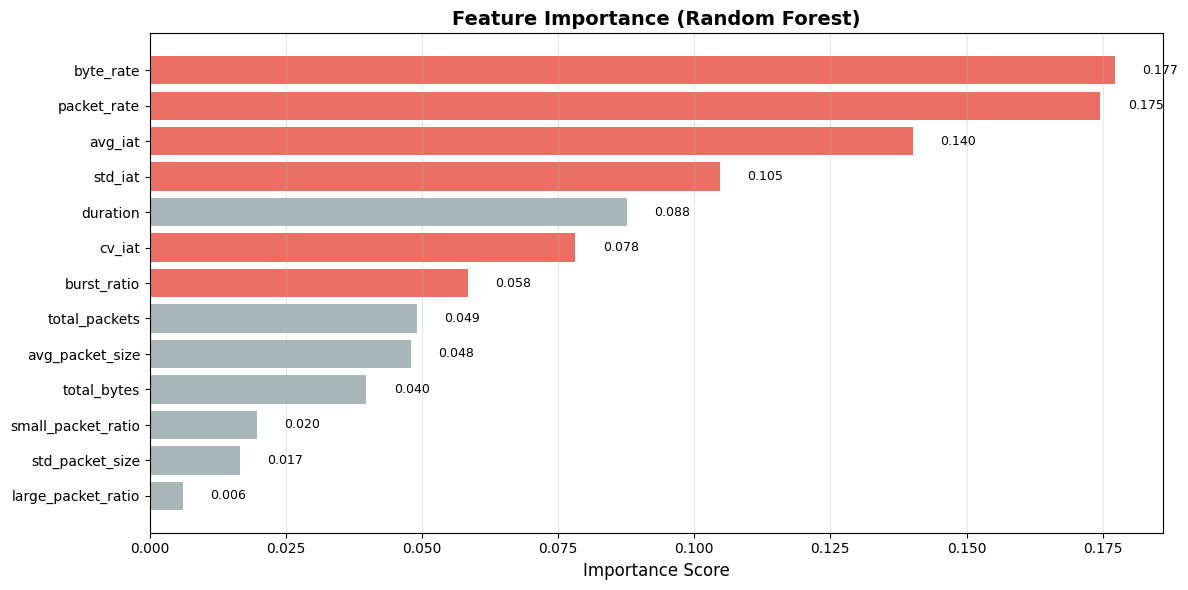


Top 6 Most Important Features:
        feature  importance
12    byte_rate    0.177301
11  packet_rate    0.174598
5       avg_iat    0.140176
6       std_iat    0.104644
0      duration    0.087564
7        cv_iat    0.078183


In [33]:
# Create bar chart
plt.figure(figsize=(12, 6))
colors = ['#e74c3c' if feat in important_features else '#95a5a6' 
          for feat in importances['feature']]

bars = plt.barh(range(len(importances)), importances['importance'], color=colors, alpha=0.8)
plt.yticks(range(len(importances)), importances['feature'])
plt.xlabel('Importance Score', fontsize=12)
plt.title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Highest importance at top
plt.grid(True, alpha=0.3, axis='x')

# Add value labels on bars
for i, (idx, row) in enumerate(importances.iterrows()):
    plt.text(row['importance'] + 0.005, i, f"{row['importance']:.3f}", 
             va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nTop 6 Most Important Features:")
print(importances.head(6))

## 10. Start Web Dashboard

### Starting the Flask API Server

The Flask API server handles inference and data storage. Start it in a terminal:

# Option 1: Using the run script
`cd web && ./run.sh`

# Option 2: Manual start
```bash
cd web
source ../venv/bin/activate
export FLASK_APP=app.py
export FLASK_ENV=development
python app.py
```
The API server runs on **http://localhost:3000**


### Starting the React Dashboard

In a separate terminal, start the React frontend:

```bash
cd web/dashboard
npm run dev
```
The dashboard runs on **http://localhost:5173**


### API Endpoints

- `POST /api/flows` - Send flow data from devices
- `GET /api/detections` - Get recent detections
- `GET /api/statistics` - Get detection statistics  
- `GET /api/devices` - List monitored devices

### Testing the API

Use the cell below to send test flows (benign and malicious) to verify the system is working.

In [16]:
import requests
import json
from datetime import datetime

# Flask API endpoint
API_URL = "http://localhost:3000/api/flows"

In [ ]:
# Recreate the same train/test split used in training
unique_sources = df['source_id'].unique()
np.random.seed(42)
np.random.shuffle(unique_sources)
split_idx = int(len(unique_sources) * 0.8)
train_sources = unique_sources[:split_idx]
test_sources = unique_sources[split_idx:]

train_mask = df['source_id'].isin(train_sources)
test_mask = df['source_id'].isin(test_sources)

X_test = df[test_mask]
y_test = df[test_mask]['label']

# Select examples from test set
benign_indices = X_test[y_test == 0].index
malicious_indices = X_test[y_test == 1].index

# Select one benign and one malicious example
benign_idx = benign_indices[0]
malicious_idx = malicious_indices[6]

print(f"Test set: {len(X_test)} flows ({len(benign_indices)} benign, {len(malicious_indices)} malicious)")
print(f"Selected benign example (index {benign_idx})")
print(f"Selected malicious example (index {malicious_idx})")

Test set: 517 flows (345 benign, 172 malicious)
Selected benign example (index 6)
Selected malicious example (index 126)


In [25]:
benign_row = df.loc[benign_idx]
benign_features = {col: float(benign_row[col]) for col in feature_cols}

benign_flow = {
    "device_id": "test-laptop-005",
    "timestamp": datetime.utcnow().isoformat(),
    "features": benign_features
}

print("Sending benign flow from test set...")
print(f"Features: duration={benign_features['duration']:.2f}s, "
      f"packet_rate={benign_features['packet_rate']:.2f}, "
      f"burst_ratio={benign_features['burst_ratio']:.3f}")
try:
    response = requests.post(API_URL, json=benign_flow, timeout=5)
    result = response.json()
    print(f"✓ Benign flow sent successfully")
    print(f"  Prediction: {result.get('prediction', 'unknown')}")
    print(f"  RF confidence: {result.get('rf_confidence', 0):.3f}")
    print(f"  SVM confidence: {result.get('svm_confidence', 0):.3f}")
except Exception as e:
    print(f"✗ Error: {e}")
    print("Make sure Flask API is running on http://localhost:3000")

Sending benign flow from test set...
Features: duration=4440.55s, packet_rate=21.36, burst_ratio=0.985
✓ Benign flow sent successfully
  Prediction: benign
  RF confidence: 0.000
  SVM confidence: 0.020


/var/folders/p2/5xvtpwg93ws2w7f9c1kk8l6w0000gn/T/ipykernel_47755/3622784748.py:6: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),


In [29]:
malicious_row = df.loc[malicious_idx]
malicious_features = {col: float(malicious_row[col]) for col in feature_cols}


malicious_flow = {
    "device_id": "test-laptop-006",
    "timestamp": datetime.utcnow().isoformat(),
    "features": malicious_features
}

print("Sending malicious flow from test set...")
print(f"Features: duration={malicious_features['duration']:.2f}s, "
      f"packet_rate={malicious_features['packet_rate']:.2f}, "
      f"burst_ratio={malicious_features['burst_ratio']:.3f}")
try:
    response = requests.post(API_URL, json=malicious_flow, timeout=5)
    result = response.json()
    print(f"✓ Malicious flow sent successfully")
    print(f"  Prediction: {result.get('prediction', 'unknown')}")
    print(f"  RF confidence: {result.get('rf_confidence', 0):.3f}")
    print(f"  SVM confidence: {result.get('svm_confidence', 0):.3f}")
except Exception as e:
    print(f"✗ Error: {e}")
    print("Make sure Flask API is running on http://localhost:3000")

Sending malicious flow from test set...
Features: duration=7669.40s, packet_rate=0.18, burst_ratio=0.463
✓ Malicious flow sent successfully
  Prediction: malicious
  RF confidence: 0.970
  SVM confidence: 0.991


/var/folders/p2/5xvtpwg93ws2w7f9c1kk8l6w0000gn/T/ipykernel_47755/2121354391.py:7: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),
